# Laboratory practice 2.2: Classification II

For this practice, you will need the following datasets:

- **Simdata.dat**: synthetic datasets containing several input variables and one output variable **Y**.

The main package for machine learning in Python is **scikit-learn**.

Further reading:
- [scikit-learn](https://scikit-learn.org)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

- Model analysis
    - [scipy](https://scipy.org/)

In [28]:
!pip install scipy==1.6.3


ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.6.3 (from versions: 

---

In [2]:
### Load necessary modules -------------------------------
# interactive plotting
#%matplotlib inline
#%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from scipy.stats import binomtest

# Custom functions for this course
from utils import *

## 1. Prepare the Dataset

In [5]:
### Load file --------------------------------------------
df = pd.read_csv('Simdata.dat', sep = "\t")
df.head()

,X1,X2,Y
0,-3.745291,3.729409,NO
1,5.806532,-4.703332,YES
2,4.209833,-0.493488,YES
3,3.429156,-2.307669,NO
4,-0.195014,2.680303,NO


In [7]:
#There are no categorical input variables

### Convert output variable to factor
df.Y = df.Y.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X1      1000 non-null   float64 
 1   X2      1000 non-null   float64 
 2   Y       1000 non-null   category
dtypes: category(1), float64(2)
memory usage: 16.9 KB


In [9]:
# Define input and output matrices
INPUTS = ['X1','X2']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

In [11]:
## Create dataset to store model predictions
dfTR_eval = X_train.copy()
dfTR_eval['Y'] = y_train # We will call Y as output variable for simplicity
dfTS_eval = X_test.copy()
dfTS_eval['Y'] = y_test # We will call Y as output variable for simplicity

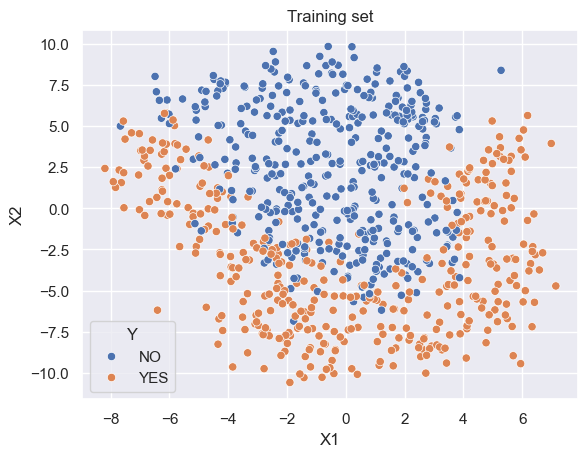

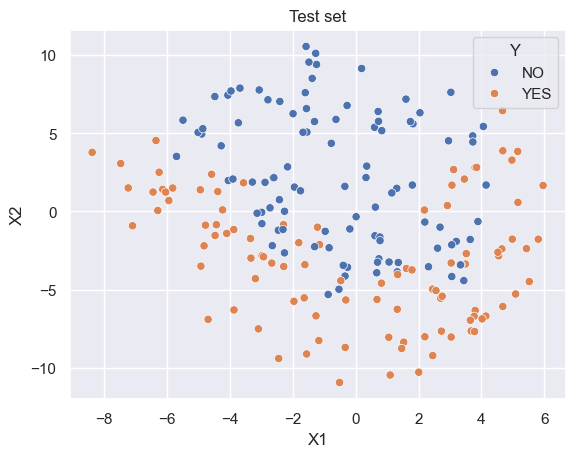

In [13]:
## plot training and test sets. 

palette = {'NO':'C0', 'YES':'C1'} # Needed to maintain color palette 
sns.scatterplot(x = 'X1', y = 'X2', hue = 'Y', data = dfTR_eval, palette=palette).set_title("Training set")
plt.show()

plt.figure() # Needed to plot two separated plots instead of two overlapped
sns.scatterplot(x = 'X1', y = 'X2', hue = 'Y', data = dfTS_eval, palette=palette).set_title("Test set")
plt.show()

## Try changing the value inside random_state attribute of train_test_split(). How does it affect the selected data?

## 2. Training of Machine Learning models

### Logistic Regression

- [LogisticRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Wikipedia](https://en.wikipedia.org/wiki/Logistic_regression)

In [17]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_LR = INPUTS

#ModLogReg = LogisticRegression()
#PIPELINE: Secuencias en un determinado orden
LogReg_fit = Pipeline(steps=[('scaler',StandardScaler()), # Preprocess the variables when training the model 
                        ('LogReg',LogisticRegression(penalty=None))]) # Model to use in the pipeline

#Train model
LogReg_fit.fit(X_train[INPUTS_LR], y_train);

print("Logistic Regression Trained")

Logistic Regression Trained


In [19]:
	

# Obtain Cross-Validation score
print("CV accuracy is")
#Saca el accuracy con el cross validation
cross_val_score(LogReg_fit, X_train[INPUTS_LR], y_train, cv=10, scoring='accuracy').mean()

CV accuracy is


0.70625

In [21]:
#Prestar atención a los asteriscos
summaryLogReg(LogReg_fit, X_train[INPUTS_LR], y_train)

Deviance Residuals:
        Min     1Q    Median      3Q       Max
0 -0.887711 -0.282 -0.001435  0.2773  0.882772

Coefficients:
           Estimate
Intercept  0.003313
X1        -0.092800
X2        -1.532975
           Estimate  Std. Err    t-value  Pr(>|t|) Signif
Intercept  0.003313  0.086313   0.038388  0.969378       
X1        -0.092800  0.084433  -1.099096  0.271726       
X2        -1.532975  0.111178 -13.788440  0.000000    ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [23]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_LR_pred'] = LogReg_fit.predict(X_train[INPUTS_LR])
dfTR_eval['Y_LR_prob_neg'] = LogReg_fit.predict_proba(X_train[INPUTS_LR])[:,0]
dfTR_eval['Y_LR_prob_pos'] = LogReg_fit.predict_proba(X_train[INPUTS_LR])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_LR_pred'] = LogReg_fit.predict(X_test)
dfTS_eval['Y_LR_prob_neg'] = LogReg_fit.predict_proba(X_test[INPUTS_LR])[:,0]
dfTS_eval['Y_LR_prob_pos'] = LogReg_fit.predict_proba(X_test[INPUTS_LR])[:,1]

#visualize evaluated data
dfTR_eval.head()

,X1,X2,Y,Y_LR_pred,Y_LR_prob_neg,Y_LR_prob_pos
601,4.155807,2.247574,YES,NO,0.713556,0.286444
717,-4.089190,-0.989964,YES,YES,0.422334,0.577666
20,-2.278323,-0.817837,YES,YES,0.447498,0.552502
523,4.207323,2.378063,YES,NO,0.722021,0.277979
344,-3.139076,-2.136547,YES,YES,0.344712,0.655288


In [108]:
def plot2DClass(X: pd.core.frame.DataFrame, y: pd.core.series.Series, model, var1:str, var2:str, selClass:str=None, np_grid=200, figsize=(10,10)):
    
# Tenemos que programar la función (curva roc)    
    
    """Create plots focused on explaining classification model performance

    Plots created by this function tries to show how the model classifies
    samples in X in 2D plots. The first plot should show the classification of
    input space by predicting the hard prediction of a grid of points with np_grid x np_grid
    resolution. The second plot should show the probabilities estimated for the input space
    for the same grid, i.e., the soft prediction. The third plot should show the true negatives,
    true positives, false negatives and false positives of the predictions of the X dataset. The 
    fourth plot should show the hard predictions of the X dataset, with contour lines with the 
    probabilities estimated for the positive class.

    Args:
        X (pd.core.frame.DataFrame): dataframe containing input variables
        y (pd.core.series.Series): series containing output variable
        model: Classification model to be analyzed
        var1 (str): name of the variable of the x-axis in the plots
        var2 (str): name of the variable of the y-axis in the plots
        selClass (str, optional): Positive class of the output variable Defaults to None.
        np_grid (int, optional): number of points of the grid in first and second plot when 
        using only two input variables. Defaults to 200.
        figsize (tuple, optional): size of figure. Defaults to (10,10).
    """
    pass

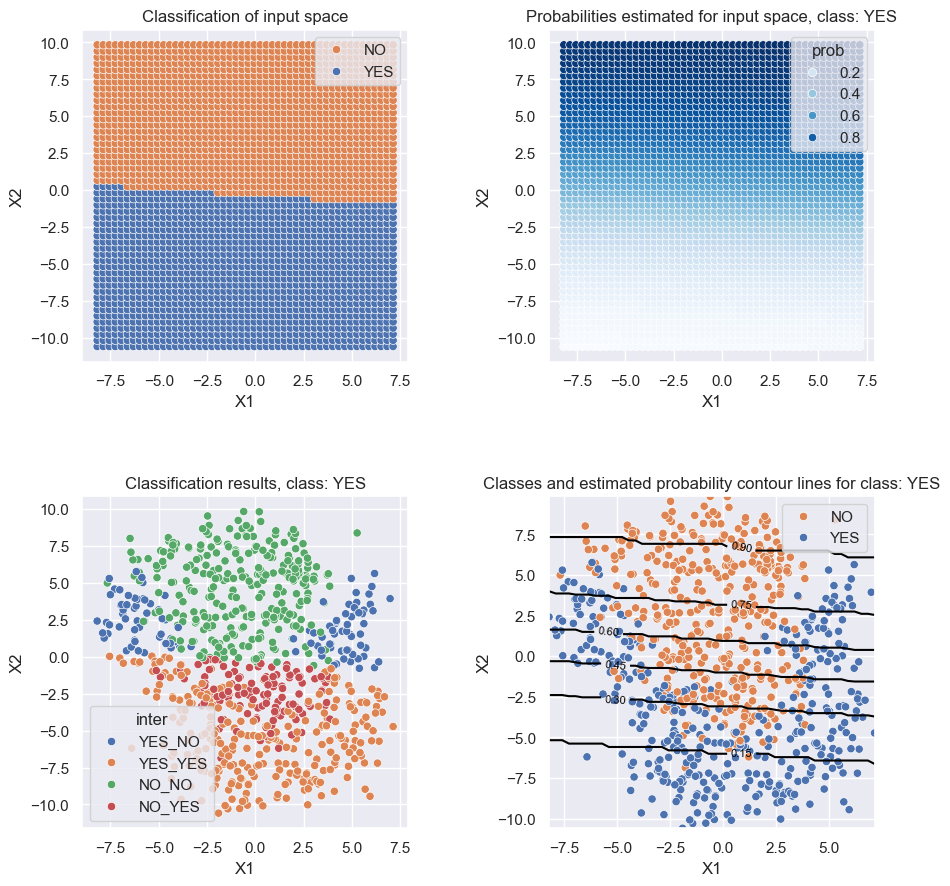

In [25]:
### Plot classification in a 2 dimensional space
from utils import plot2DClass

plot2DClass(X_train[INPUTS_LR], dfTR_eval['Y'], LogReg_fit, 'X1', 'X2', 'YES', 50) 

#### Confusion matrix
- [confusion_matrix()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix)
- [Wikipedia](https://en.wikipedia.org/wiki/Confusion_matrix)
- [accuracy_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)
- [precision_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)
- [recall_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)
- [f1_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

In [111]:
def confusion_matrix(y_true:pd.core.series.Series, y_pred:pd.core.series.Series, labels, sample_weight=None, normalize:bool=True):
    """Calculate confusion matrix and classification metrics

    This function should calculate and show the confusion matrix of the predictions of the model, and a list of
    classification metrics. The confusion matrix should be normalized if normalize is set to True. The classification
    metrics calculated should be: accuracy, precision, recall and f1-score. 

    Args:
        y_true (pd.core.series.Series): Series containing true values of output
        y_pred (pd.core.series.Series): Series containing predicted values of output
        labels [str,str,str,...]: String vector of output categories
        sample_weight ([int, int, ...], optional): Weights assigned to output samples in training process. Defaults to None.
        normalize (bool, optional): normalize classification metrics when possible. Defaults to True.
    """
    pass

In [27]:
#Confusion matrix for Log Reg Model
print("----- TRAINING CONFUSION MATRIX -----")
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_LR_pred'],labels=['NO','YES'])

----- TRAINING CONFUSION MATRIX -----
Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 281  119
      YES 116  284

Accuracy: 0.71
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.41
Mcnemar's Test P-Value: 0.9
Sensitivity: 0.71
Specificity: 0.7
Precision: 0.71
Recall: 0.7
Prevalence: 0.5
Detection Rate: 0.36
Detection prevalence: 0.5
Balanced accuracy: 0.71
F1 Score: 0.71
Positive label: NO


In [29]:
print("----- TEST CONFUSION MATRIX-----")
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_LR_pred'],labels=['NO','YES'])

----- TEST CONFUSION MATRIX-----
Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  65   35
      YES  28   72

Accuracy: 0.69
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.37
Mcnemar's Test P-Value: 0.45
Sensitivity: 0.72
Specificity: 0.65
Precision: 0.7
Recall: 0.65
Prevalence: 0.5
Detection Rate: 0.36
Detection prevalence: 0.54
Balanced accuracy: 0.68
F1 Score: 0.67
Positive label: NO


In [114]:
def plotClassPerformance(y: pd.core.series.Series, prob_est: pd.core.frame.DataFrame, selClass:str=None, figsize=(10,5)):
    """Create plots associated to model binary classification performance based on output assigned probabilities.

    The first plot should be the calibration curve (https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html).
    The second plot should be two subplots with the histogram of probability of being positive class for the negative samples (P(Y_pred=positive/Y_real=negative)) 
    and for the positive samples (P(Y_pred=positive/Y_real=positive)). The third plot should be the ROC curve of the model, including the AUC value.
    The fourth plot should be the accuracy metric of the model for different thresholds of the predicted probabilities (threshold from 0 to 1 in steps of 0.01).

    Args:
        y (pd.core.series.Series): Series containing true values of output 
        prob_est (pd.core.frame.DataFrame): Dataframe containing predicted categories probabilities of output
        selClass (str, optional): Positive class of the output. Defaults to None.
        figsize (Tuple[float, float], optional): Size of plot figures. Defaults to (10,5).
    """
    pass

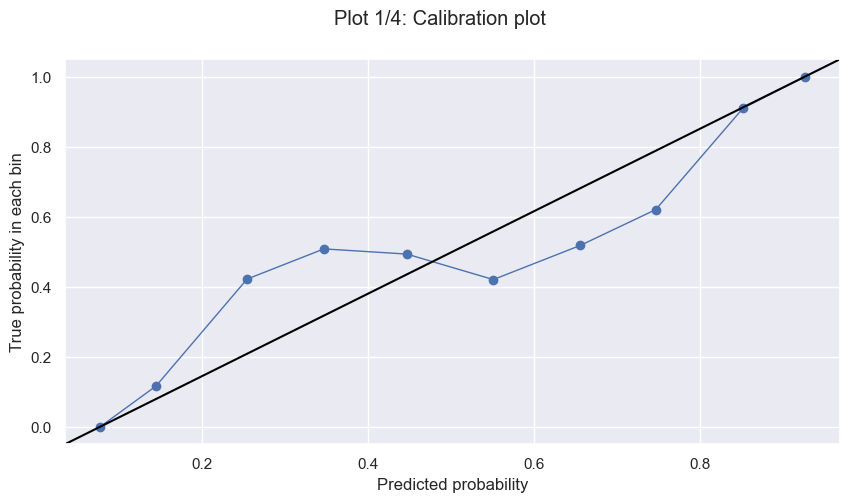

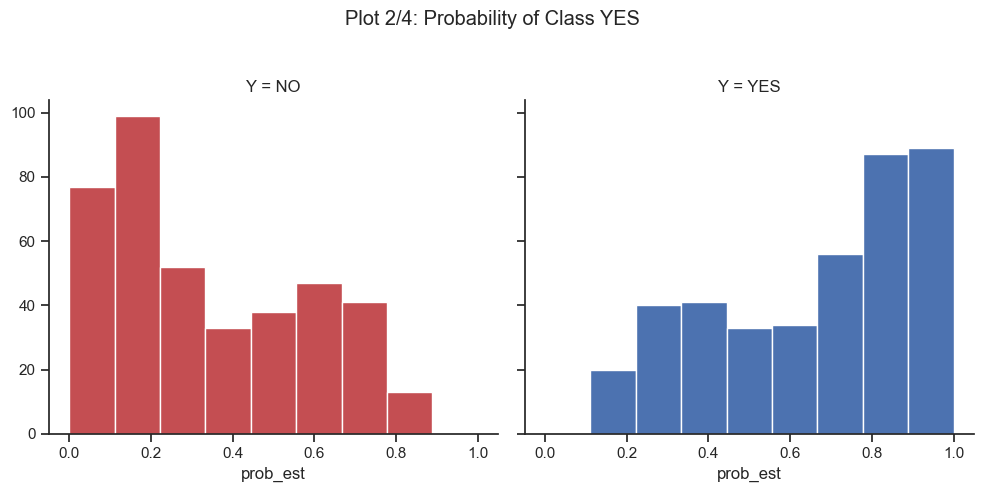

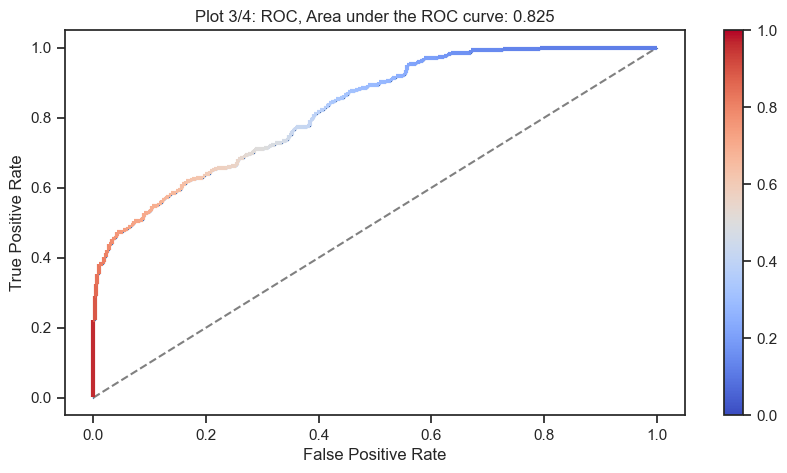

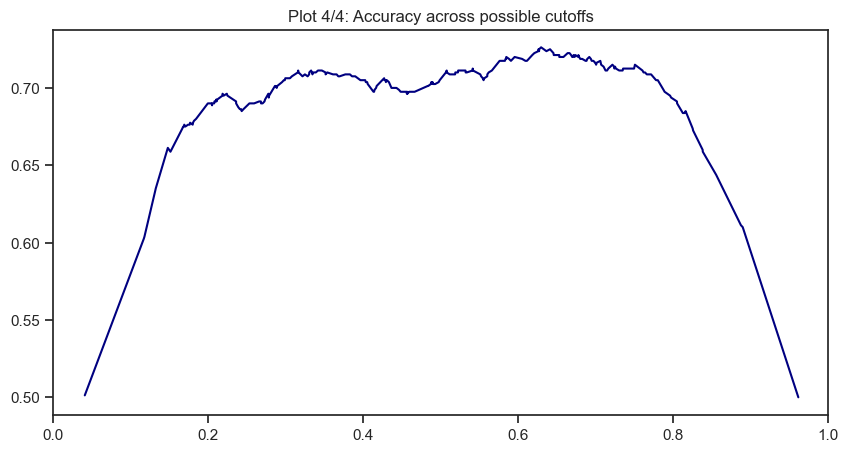

In [31]:
plotClassPerformance(dfTR_eval['Y'], LogReg_fit.predict_proba(X_train[INPUTS_LR]), selClass='YES')

---
### Non-linear & categorical input

In [33]:
## Inputs of the model. Change accordingly to perform variable selection
INPUTS_LR2_NUM = ["X2"]
INPUTS_LR2_SQ = ["X1"]
INPUTS_LR2_CAT = []
INPUTS_LR2 = INPUTS_LR2_NUM + INPUTS_LR2_SQ + INPUTS_LR2_CAT

# Prepare the numeric variables by scaling
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Prepare the numeric variables by scaling
#Añadimos el x^2 com variable, lo que nos permite mejorar nuestro modelo
square_transformer = Pipeline(steps=[('scaler', StandardScaler()),
                                      ('Poly',PolynomialFeatures())])

# Prepare the categorical variables by encoding the categories
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor to perform the steps defined above
preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, INPUTS_LR2_NUM),
        ('sq', square_transformer, INPUTS_LR2_SQ),
        ('cat', categorical_transformer, INPUTS_LR2_CAT)
        ])

pipe = Pipeline(steps=[('Prep',preprocessor), # Preprocess the variables when training the model 
                       ('LogReg',LogisticRegression(fit_intercept=False, penalty=None))]) # Avoid using intercept when using polynomial features

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
param = {}
LogReg_fit_sq = GridSearchCV(estimator=pipe, # Structure of the model to use
                            param_grid=param, # Defined grid to search in
                            n_jobs=-1, # Number of cores to use (parallelize)
                            scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                            cv=nFolds) # Number of Folds 
#Train model
LogReg_fit_sq.fit(X_train[INPUTS_LR2], y_train)

print("Logistic Regression Trained")

Logistic Regression Trained


In [35]:
# Obtain Cross-Validation score
print("CV accuracy is")
cross_val_score(LogReg_fit_sq, X_train[INPUTS_LR2], y_train, cv=10, scoring='accuracy').mean()

CV accuracy is


0.8675

In [37]:
summaryLogReg(LogReg_fit_sq.best_estimator_, X_train[INPUTS_LR2], y_train)

Deviance Residuals:
        Min        1Q    Median        3Q       Max
0 -0.997518 -0.036113 -0.000032  0.066917  0.937425

Coefficients:
      Estimate
X2   -3.331489
1    -2.783318
X1    0.106251
X1^2  2.631963
      Estimate  Std. Err    t-value  Pr(>|t|) Signif
X2   -3.331489  0.267547 -12.451985  0.000000    ***
1    -2.783318  0.261748 -10.633599  0.000000    ***
X1    0.106251  0.134580   0.789501  0.429819       
X1^2  2.631963  0.219156  12.009559  0.000000    ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [39]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_LR_sq_pred'] = LogReg_fit_sq.predict(X_train[INPUTS_LR2])
dfTR_eval['Y_LR_sq_prob_neg'] = LogReg_fit_sq.predict_proba(X_train[INPUTS_LR2])[:,0]
dfTR_eval['Y_LR_sq_prob_pos'] = LogReg_fit_sq.predict_proba(X_train[INPUTS_LR2])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_LR_sq_pred'] = LogReg_fit_sq.predict(X_test[INPUTS_LR2])
dfTS_eval['Y_LR_sq_prob_neg'] = LogReg_fit_sq.predict_proba(X_test[INPUTS_LR2])[:,0]
dfTS_eval['Y_LR_sq_prob_pos'] = LogReg_fit_sq.predict_proba(X_test[INPUTS_LR2])[:,1]

#visualize evaluated data
dfTR_eval.head()

,X1,X2,Y,Y_LR_pred,Y_LR_prob_neg,Y_LR_prob_pos,Y_LR_sq_pred,Y_LR_sq_prob_neg,Y_LR_sq_prob_pos
601,4.155807,2.247574,YES,NO,0.713556,0.286444,NO,0.538235,0.461765
717,-4.089190,-0.989964,YES,YES,0.422334,0.577666,YES,0.273942,0.726058
20,-2.278323,-0.817837,YES,YES,0.447498,0.552502,NO,0.822224,0.177776
523,4.207323,2.378063,YES,NO,0.722021,0.277979,NO,0.534524,0.465476
344,-3.139076,-2.136547,YES,YES,0.344712,0.655288,YES,0.423621,0.576379


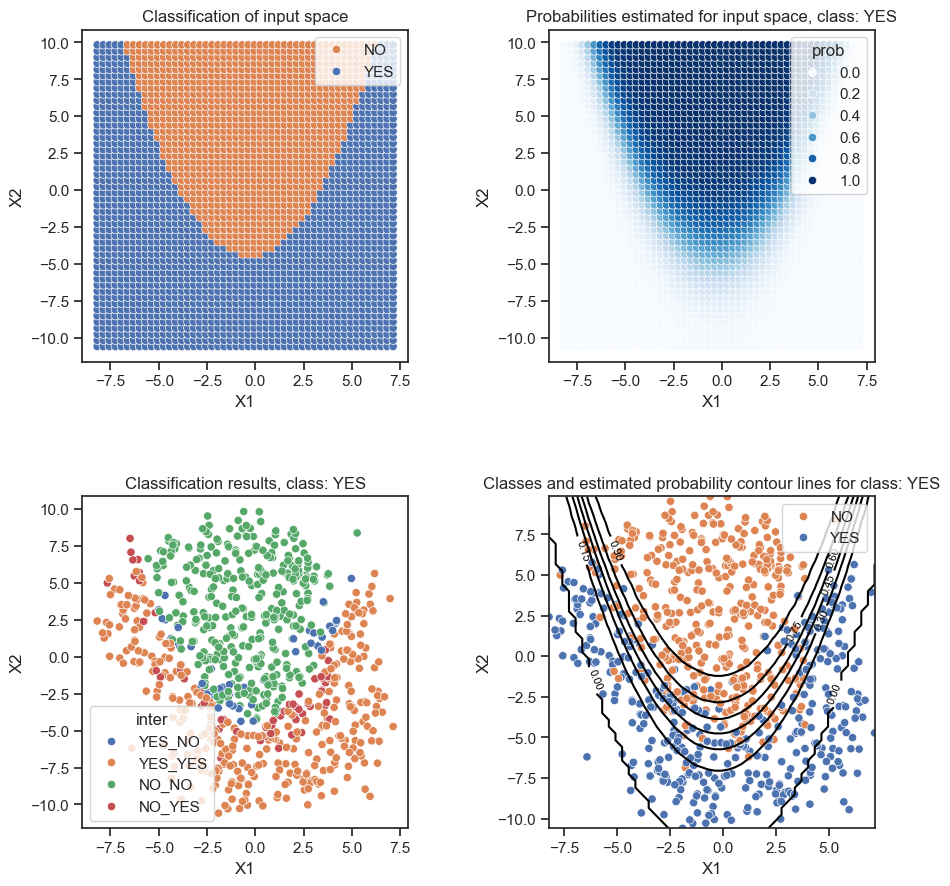

In [41]:
### Plot classification in a 2 dimensional space
plot2DClass(X_train[INPUTS_LR2], dfTR_eval['Y'], LogReg_fit_sq, 'X1', 'X2', 'YES', 50) 

In [43]:
#Confusion matrix for Log Reg Model
print("----- TRAINING CONFUSION MATRIX -----")
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_LR_sq_pred'], labels=['NO','YES'])

----- TRAINING CONFUSION MATRIX -----
Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 342   58
      YES  48  352

Accuracy: 0.87
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.74
Mcnemar's Test P-Value: 0.38
Sensitivity: 0.88
Specificity: 0.86
Precision: 0.88
Recall: 0.86
Prevalence: 0.5
Detection Rate: 0.44
Detection prevalence: 0.51
Balanced accuracy: 0.87
F1 Score: 0.87
Positive label: NO


In [44]:
print("----- TEST CONFUSION MATRIX-----")
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_LR_sq_pred'], labels=['NO','YES'])

----- TEST CONFUSION MATRIX-----
Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  85   15
      YES  18   82

Accuracy: 0.83
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.67
Mcnemar's Test P-Value: 0.73
Sensitivity: 0.82
Specificity: 0.85
Precision: 0.83
Recall: 0.85
Prevalence: 0.5
Detection Rate: 0.41
Detection prevalence: 0.48
Balanced accuracy: 0.84
F1 Score: 0.84
Positive label: NO


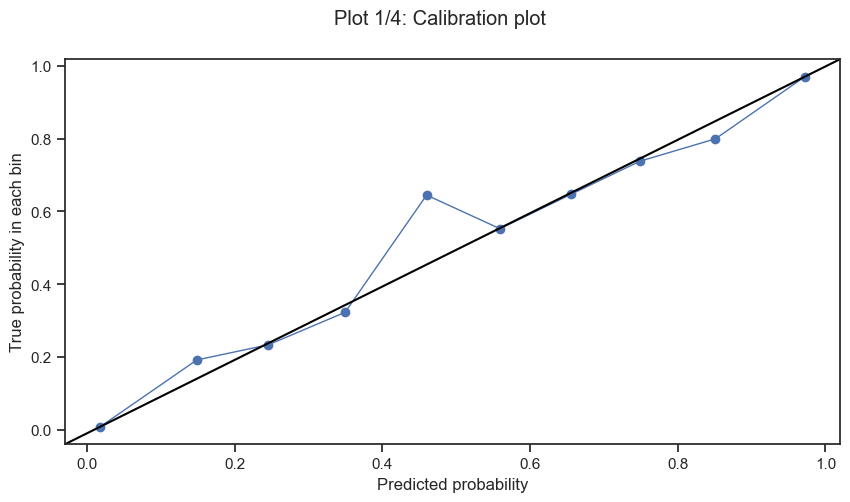

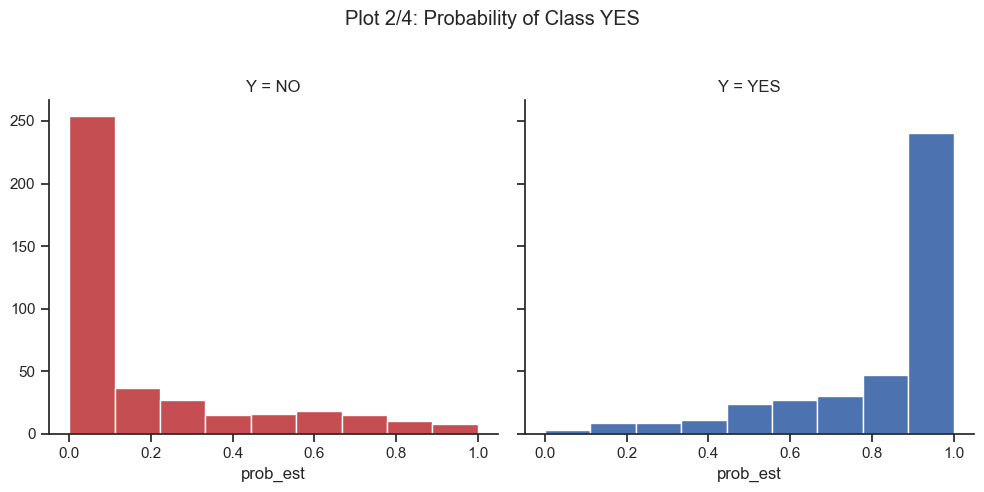

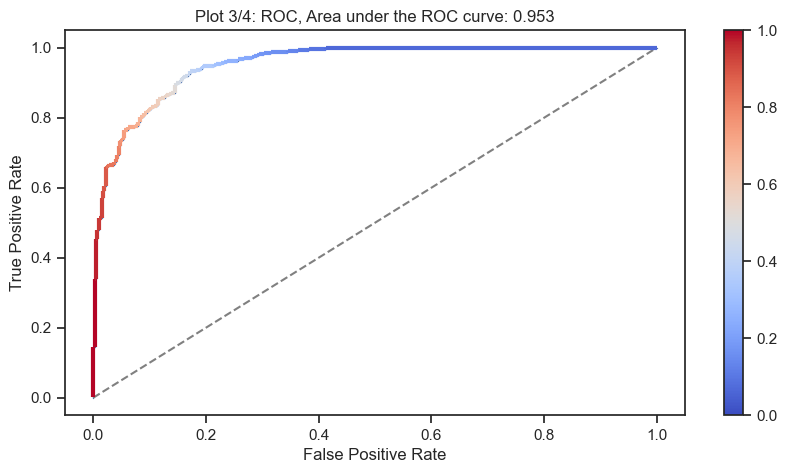

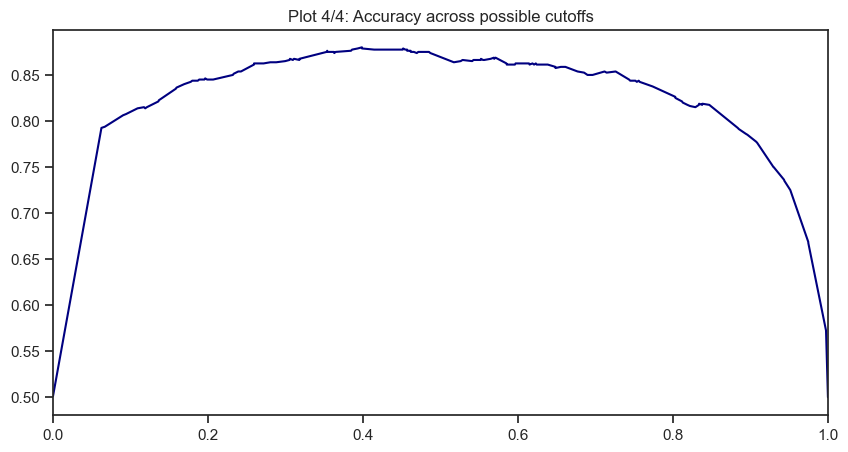

In [47]:
plotClassPerformance(dfTR_eval['Y'], LogReg_fit_sq.predict_proba(X_train[INPUTS_LR2]), selClass='YES')

---

### K-Nearest Neighbours
- [K-Nearest Neighbours](https://scikit-learn.org/stable/modules/neighbors.html#classification)
- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

Before using the majestic functions from scikit learn, let's do it by hand. This would allow us to understand in depth the process being done under the hood and to know what to fix is something goes wrong in future training processes. The idea is the following:

Parameters: 
- $n\_folds$: number of folds to use during cross-validation.
- $k$: KNN hyperparameter grid.
- $df$: Input dataset with input and output variables.

1. For each value of $k$:<br>
    2. Split the data into $n\_folds$ folds to perform cross-validation<br>
    3. For each iteration in a sequence from 0 to $n\_folds$ -> np.arange(n_folds):<br>
        3.1- Leaves one fold for validation, and scaled the rest of the folds using a ```StandardScaler()``` from ```scikit-learn``` <br>
        3.2- Train a KNN model with $k$ as the number of neighbors. <br>
        3.3- Calculate and store the error metric of your choosing (for example, the accuracy) of the validation fold.<br>
    4. Obtain the mean and standard deviation of the stored validation errors.
2. Choose $k\_optimal$ as the $k$ with the lowest validation error (i.e. highest validation accuracy)
3. Train a new model with $k\_optimal$ and the whole input dataset.
4. Return $k\_optimal$, the optimal model and the mean and standard deviation of validation errors stored.

In [128]:
# You are allowed to use the following functions from sklearn
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def knn_cross_validation(n_folds, k_values, X_train, y_train):
    """
    Perform k-Nearest Neighbors (kNN) cross-validation to find the optimal value of k.

    This function performs k-fold cross-validation using the kNN algorithm from scikit-learn.
    It evaluates different values of k (number of neighbors) and selects the one that gives 
    the highest validation accuracy. The function then trains a final kNN model using the 
    entire dataset with the optimal value of k.

    Args:
        n_folds (int): The number of folds to use in cross-validation.
        k_values (list of int): A list of k values (number of neighbors) to evaluate.
        X_train (np.ndarray): The input features as a NumPy array.
        y_train (np.ndarray): The target variable as a NumPy array.

    Returns:
        tuple: A tuple containing:
            - k_optimal (int): The value of k with the highest validation accuracy.
            - final_knn (KNeighborsClassifier): A trained kNN model using the optimal k 
              on the entire dataset.

    Example:
        >>> X_train = np.array([[1, 2], [2, 4], [3, 6], [4, 8], [5, 10], [6, 12]])
        >>> y_train = np.array([0, 0, 0, 1, 1, 1])
        >>> k_values = [1, 3, 5]
        >>> n_folds = 3
        >>> k_optimal, final_model = knn_cross_validation(n_folds, k_values, X_train, y_train)
    """
    
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Dictionary to store the mean validation accuracy for each k
    k_accuracies = {}

    # Loop over each k in the grid
    for k in k_values:

        # Perform cross-validation
        for train_index, val_index in kf.split(X_train):
            pass


    # Find the optimal k with the highest accuracy
    k_optimal = None

    # Train the final kNN model using the optimal k
    final_knn = KNeighborsClassifier(n_neighbors=k_optimal)

    return k_optimal, final_knn

k_values = range(3, 135, 4)
n_folds = 10

knn_cross_validation(n_folds, k_values, X_train, y_train)

(None, KNeighborsClassifier(n_neighbors=None))

The code below does the same as your function using scikit:

In [49]:
#---------- KNN MODEL ------------------

## Inputs of the model. Change accordingly to
INPUTS_KNN = INPUTS

## Configure model and hyparameter tuning
param = {'knn__n_neighbors': range(3, 135, 4)} #Number of neighbors
# param = {'knn__n_neighbors': [150]} # Uncomment in case only one parameter is wanted

# Scale data previous to fit
pipe = Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
knn_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                        param_grid=param, # Defined grid to search in
                        n_jobs=-1, # Number of cores to use (parallelize)
                        scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                        cv=nFolds) # Number of Folds 

# Search in grid and train model --------------------
knn_fit.fit(X_train[INPUTS_KNN], y_train) 

print("kNN Trained")

kNN Trained


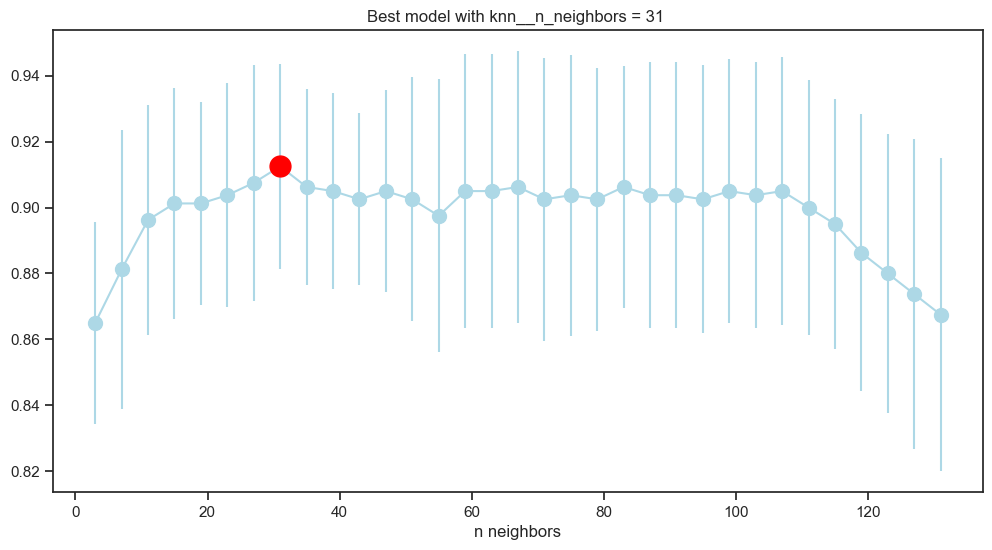

In [51]:
plotModelGridError(knn_fit)

#nos quedamos con el de menos varianza, pues es mas consistente. A igual media, menor varianza.
#nos interesa ir hacia la derecha, (las islas son mas suaves). Nos asegura que al ver datos de test nuestro modelo no haga "locuras".
#la probabilidad en KNN se saca con la regla de laplaca

In [53]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_knn_pred'] = knn_fit.predict(X_train[INPUTS_KNN])
dfTR_eval['Y_knn_prob_neg'] = knn_fit.predict_proba(X_train[INPUTS_KNN])[:,0]
dfTR_eval['Y_knn_prob_pos'] = knn_fit.predict_proba(X_train[INPUTS_KNN])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_knn_pred'] = knn_fit.predict(X_test[INPUTS_KNN])
dfTS_eval['Y_knn_prob_neg'] = knn_fit.predict_proba(X_test[INPUTS_KNN])[:,0]
dfTS_eval['Y_knn_prob_pos'] = knn_fit.predict_proba(X_test[INPUTS_KNN])[:,1]

<Figure size 1000x1000 with 0 Axes>

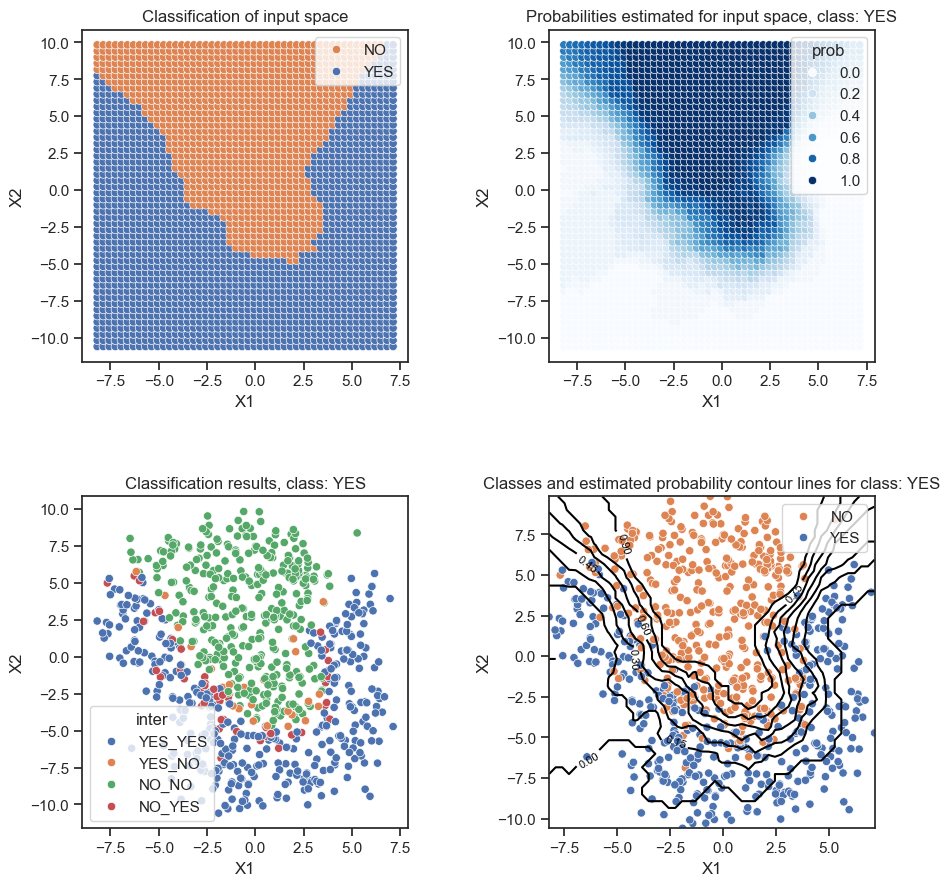

In [55]:
### Plot classification in a 2 dimensional space
plt.figure(figsize=(10, 10))
plot2DClass(X_train[INPUTS_KNN], dfTR_eval['Y'], knn_fit, 'X1', 'X2', 'YES', 50) 

In [57]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_knn_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 355   45
      YES  27  373

Accuracy: 0.91
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.82
Mcnemar's Test P-Value: 0.04
Sensitivity: 0.93
Specificity: 0.89
Precision: 0.93
Recall: 0.89
Prevalence: 0.5
Detection Rate: 0.47
Detection prevalence: 0.52
Balanced accuracy: 0.91
F1 Score: 0.91
Positive label: NO


In [59]:
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_knn_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  88   12
      YES  13   87

Accuracy: 0.88
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.75
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.87
Specificity: 0.88
Precision: 0.87
Recall: 0.88
Prevalence: 0.5
Detection Rate: 0.44
Detection prevalence: 0.5
Balanced accuracy: 0.88
F1 Score: 0.88
Positive label: NO


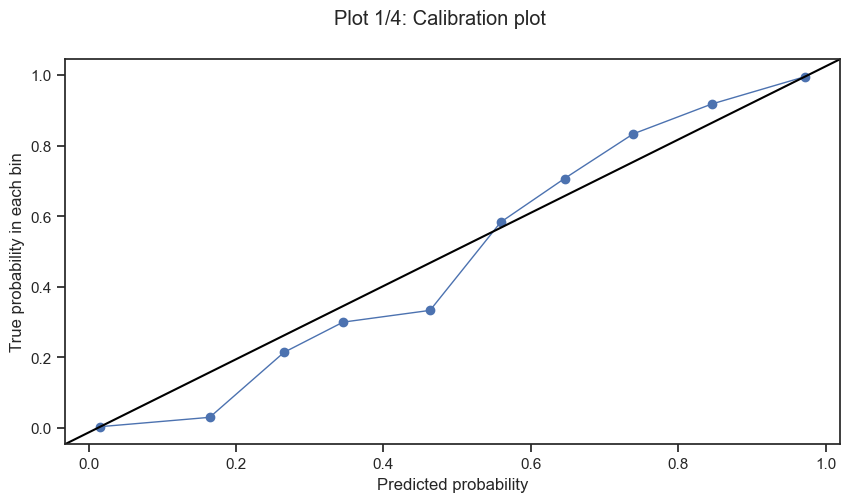

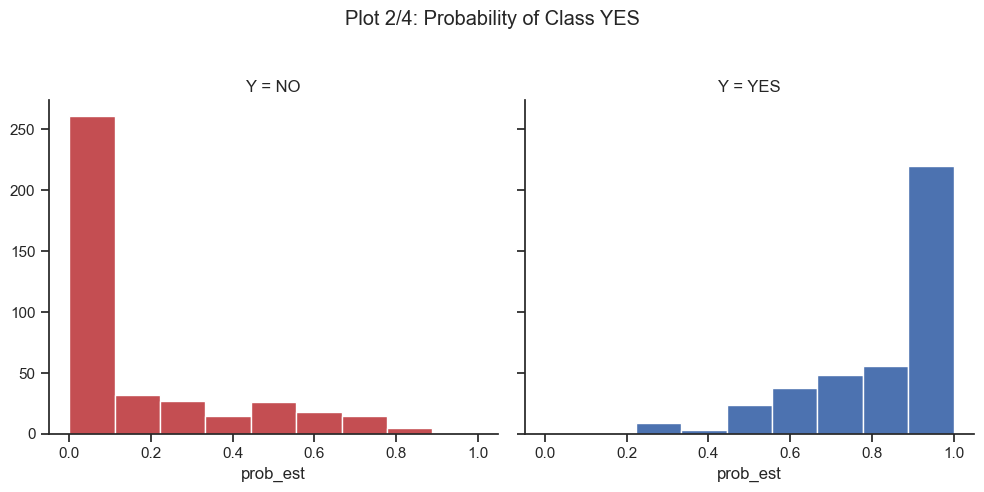

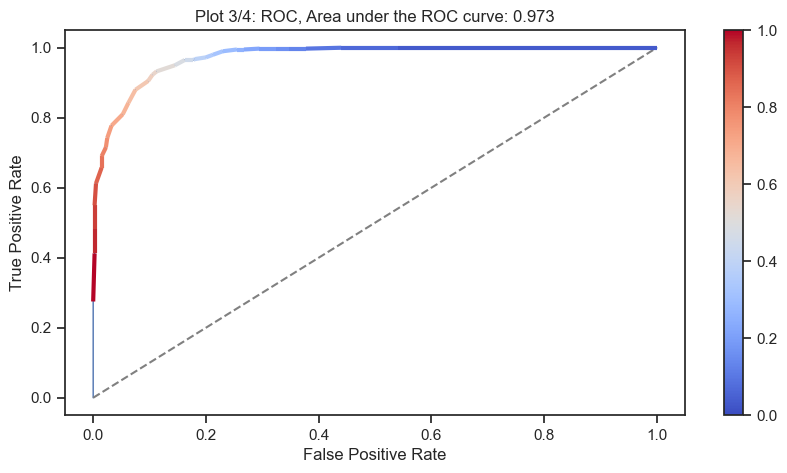

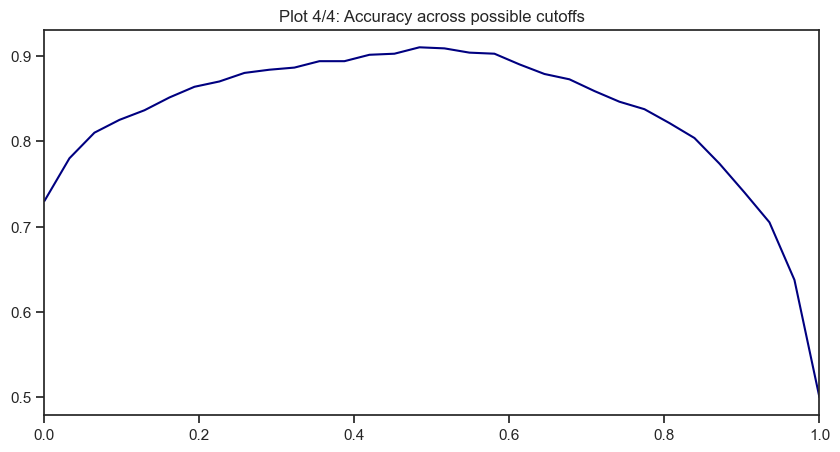

In [61]:
plotClassPerformance(dfTR_eval['Y'], knn_fit.predict_proba(X_train[['X1','X2']]), selClass='YES')

In [ ]:
#los histogramas de si y no tiendes a los extremos ----> están bien
